## Homework 4
ELENE4730 Quantum Optimization and Machine Learning

Daniel Vitenko

In [3]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
import matplotlib.pyplot as plt
import numpy as np


In [14]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
ibmsampler = Sampler(mode=backend)

qiskit_runtime_service.__init__:WARNING:2026-02-26 13:44:43,925: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-26 13:44:45,565: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-26 13:44:50,041: Using instance: open-instance, plan: open


In [4]:
%matplotlib inline

## Problem 1

In [72]:
def deutsch_a():
    qc = QuantumCircuit(2,1)

    qc.x(1)
    qc.h(0)
    qc.h(1)

    #oracle f(x) = ¬x
    qc.cx(0,1)
    qc.x(1)

    qc.h(0)
    qc.measure(0,0)

    return qc

def deutsch_b():
    qc = QuantumCircuit(2,1)

    qc.x(1)
    qc.h(0)
    qc.h(1)

    #oracle f(x) = x + ¬x = 1
    qc.x(1)

    qc.h(0)
    qc.measure(0,0)

    return qc


## (a)

Counts: {'1': 1024}
Counts: {'1': 110, '0': 18}


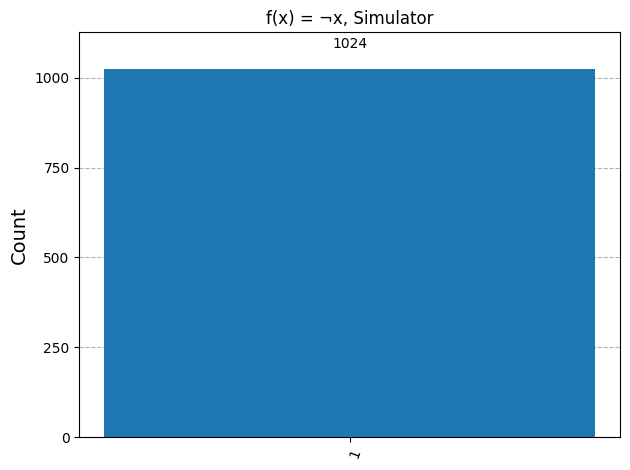

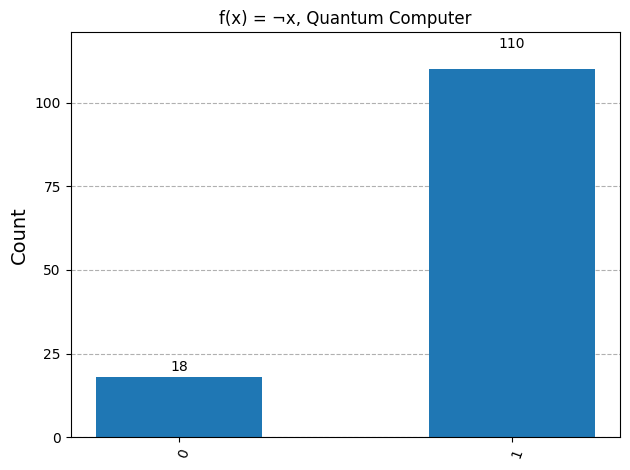

In [73]:
qc = deutsch_a()

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="f(x) = ¬x, Simulator");

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="f(x) = ¬x, Quantum Computer");


## (b)

Counts: {'0': 1024}
Counts: {'0': 118, '1': 10}


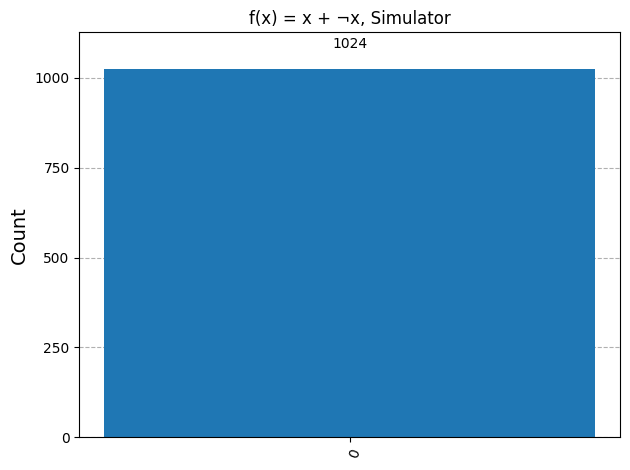

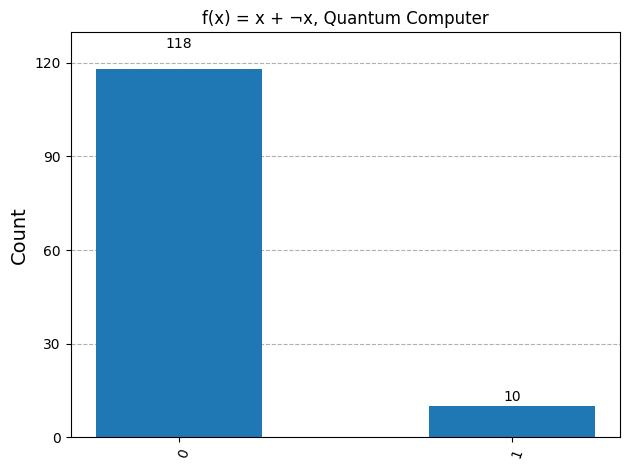

In [74]:
qc = deutsch_b()

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="f(x) = x + ¬x, Simulator");

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="f(x) = x + ¬x, Quantum Computer");

## Problem 2

In [75]:
def oracle(qc, target):
    for i, b in enumerate(reversed(target)):
        if b == "0":
            qc.x(i)

    qc.h(4)
    qc.mcx([0,1,2,3], 4)
    qc.h(4)

    for i, b in enumerate(reversed(target)):
        if b == "0":
            qc.x(i)

def diffuser(qc):
    for qubit in qc.qubits:
        qc.h(qubit)
        qc.x(qubit)
    
    qc.h(4)
    qc.mcx([0,1,2,3], 4)
    qc.h(4)

    for qubit in qc.qubits:
        qc.x(qubit)
        qc.h(qubit)

def grover(target, iterations):
    qc = QuantumCircuit(5)

    # initialize
    for qubit in qc.qubits:
        qc.h(qubit)

    for _ in range(iterations):
        # apply oracle to each target state
        for i in range(len(target)):
            oracle(qc, target[i])
        diffuser(qc)

    qc.measure_all()
    return qc

## (a)

Counts(ideal): {'10000': 1023, '10011': 1}
Counts: {'00101': 5, '10111': 4, '10101': 4, '11110': 7, '00110': 4, '01010': 3, '00100': 4, '01110': 5, '01001': 2, '11010': 5, '00000': 3, '01011': 3, '00010': 5, '11111': 3, '01100': 2, '10000': 7, '01111': 8, '00001': 7, '00111': 6, '11000': 3, '11001': 2, '10110': 2, '01101': 5, '10011': 7, '11011': 4, '11100': 4, '10001': 7, '10100': 1, '10010': 2, '01000': 2, '00011': 2}
Counts(ideal): {'10000': 921, '01010': 5, '10101': 6, '10100': 3, '00011': 5, '10001': 4, '01110': 1, '11001': 4, '10011': 5, '00101': 2, '01001': 4, '00110': 3, '10110': 4, '11100': 2, '00100': 4, '01101': 2, '00010': 3, '00000': 5, '00111': 3, '01000': 1, '11111': 3, '00001': 3, '11011': 4, '11110': 3, '11000': 4, '01100': 2, '11010': 2, '10010': 3, '01111': 4, '01011': 3, '10111': 3, '11101': 3}
Counts: {'11001': 6, '11110': 5, '00001': 6, '00010': 3, '10101': 5, '01010': 5, '01100': 5, '11011': 3, '10000': 7, '01011': 5, '00111': 7, '01111': 7, '10111': 5, '00011': 

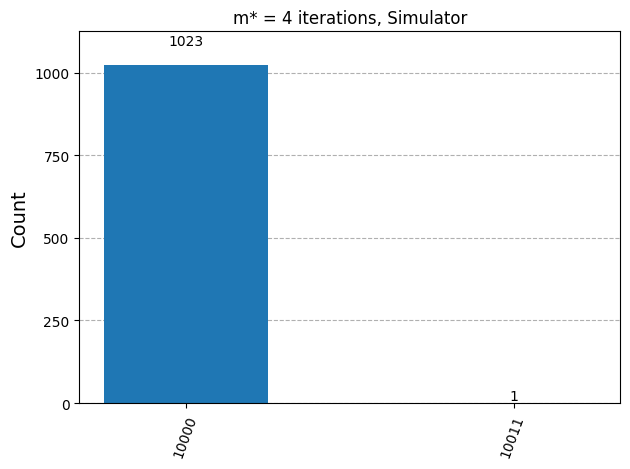

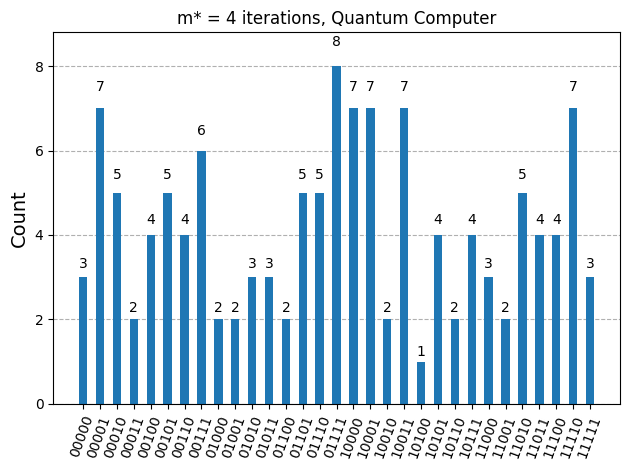

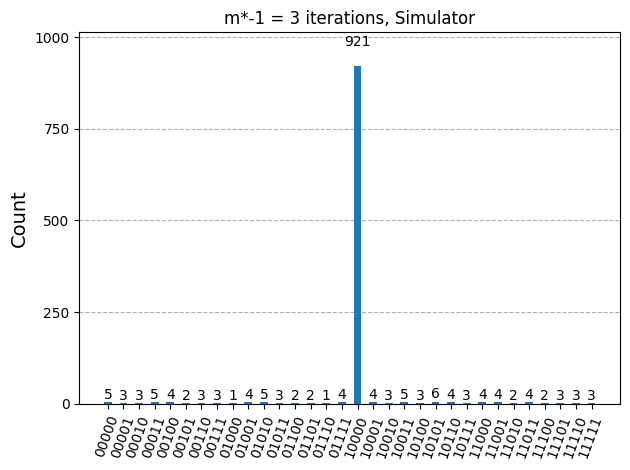

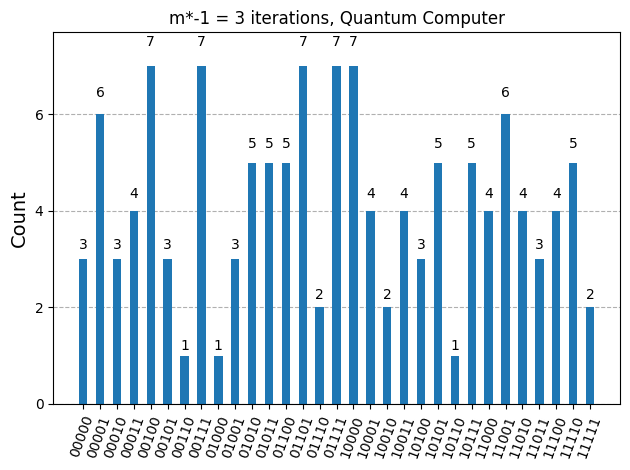

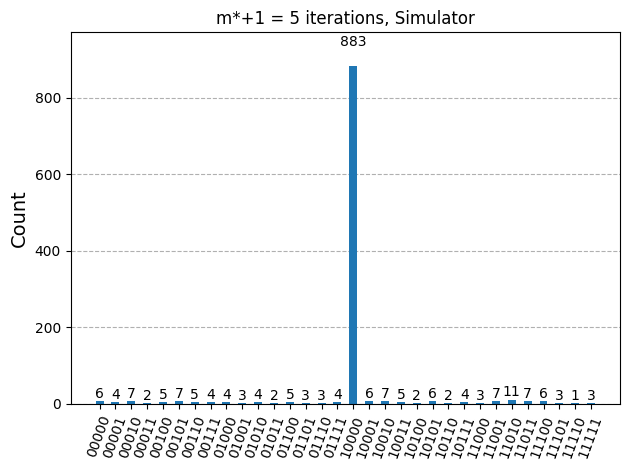

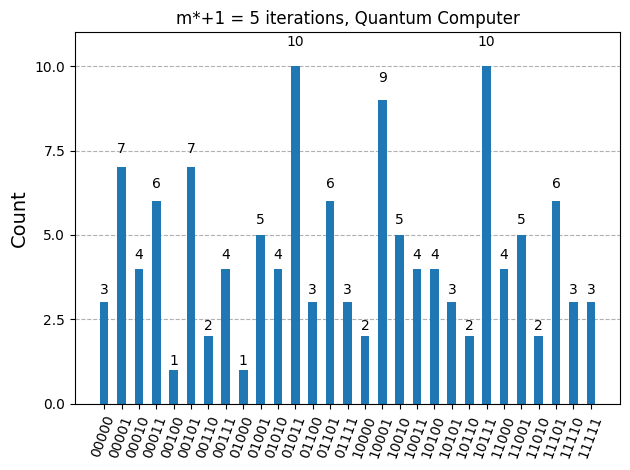

In [81]:
target = ["10000"]
iterations = int(np.floor((np.pi/4) * np.sqrt(2**5)))

# m* = 4 iterations
qc = grover(target, iterations)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts, title="m* = 4 iterations, Simulator");

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.meas.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="m* = 4 iterations, Quantum Computer");

# m*-1 = 3 iterations
qc = grover(target, iterations-1)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts, title="m*-1 = 3 iterations, Simulator");

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.meas.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="m*-1 = 3 iterations, Quantum Computer");


# m*+1 = 5 iterations
qc = grover(target, iterations+1)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts, title="m*+1 = 5 iterations, Simulator");

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.meas.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="m*+1 = 5 iterations, Quantum Computer");


# (b)

Counts(ideal): {'11110': 469, '00001': 511, '01101': 1, '11111': 2, '01000': 3, '00000': 1, '00111': 1, '11011': 2, '10000': 1, '10101': 3, '10010': 1, '10100': 5, '01010': 2, '11010': 1, '01100': 4, '10110': 3, '11001': 4, '00110': 2, '01111': 1, '00011': 1, '10111': 1, '00101': 3, '11000': 1, '01001': 1}
Counts: {'00101': 3, '00011': 7, '10001': 4, '10101': 8, '01110': 3, '10100': 10, '00110': 4, '11000': 2, '01001': 3, '00100': 6, '00000': 5, '11111': 4, '11001': 2, '01000': 4, '10000': 4, '01100': 4, '11010': 1, '01101': 3, '10110': 5, '11101': 4, '10010': 4, '01010': 2, '00111': 5, '01111': 4, '11100': 3, '11110': 4, '01011': 4, '10011': 3, '00010': 6, '11011': 2, '10111': 3, '00001': 2}
Counts(ideal): {'01110': 3, '10101': 5, '00001': 489, '11110': 439, '01011': 3, '01010': 7, '00111': 4, '10100': 6, '00110': 4, '11100': 5, '11000': 3, '11001': 6, '10000': 5, '10001': 4, '11101': 3, '00100': 3, '01000': 4, '01111': 4, '00000': 1, '01001': 2, '10110': 2, '11111': 2, '00011': 5, '0

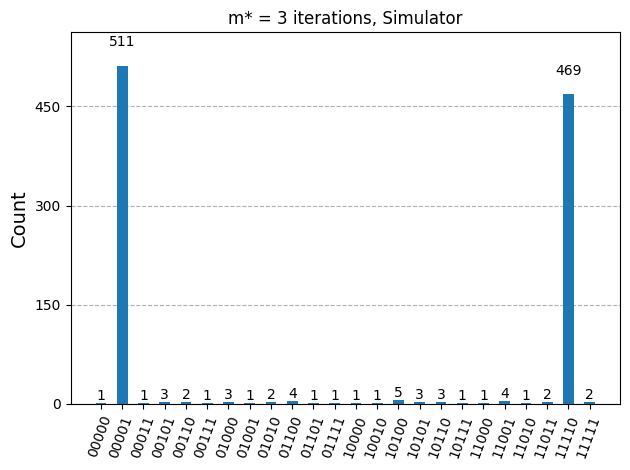

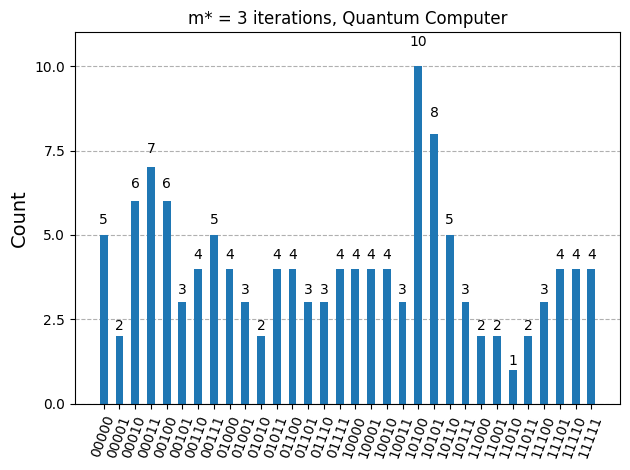

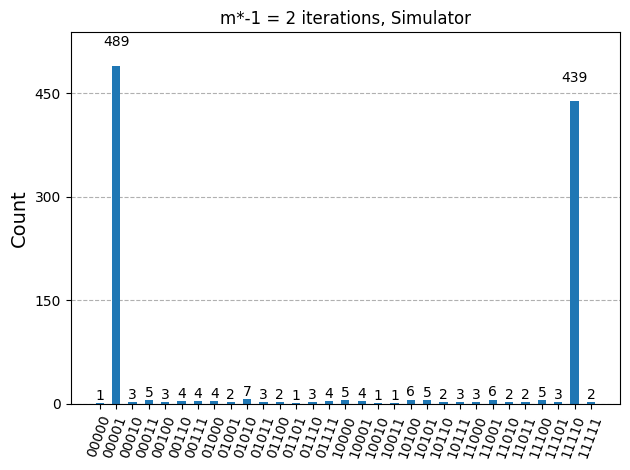

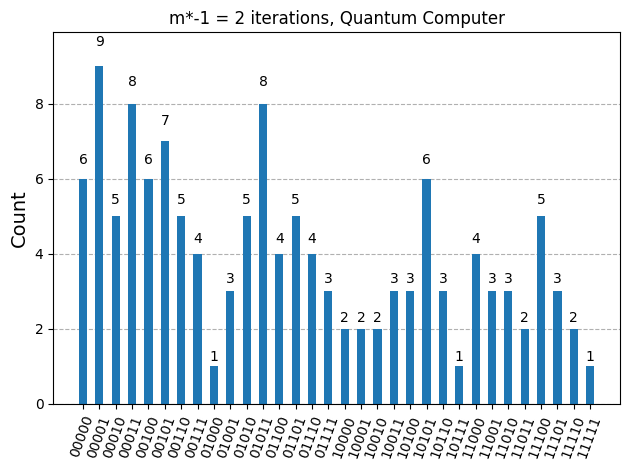

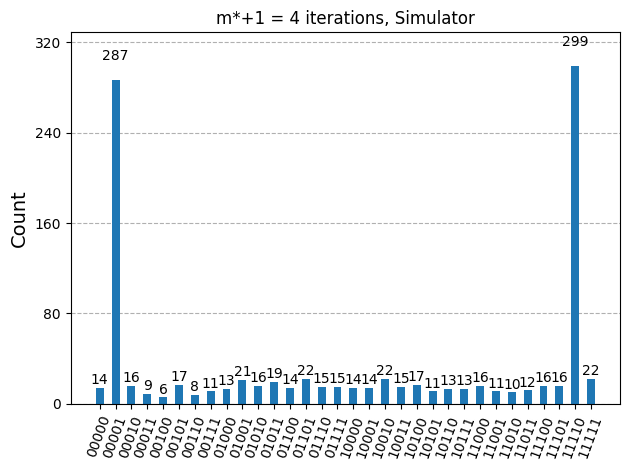

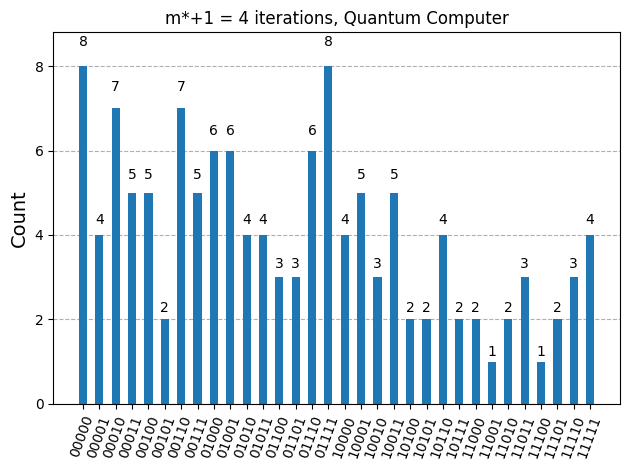

In [83]:
target = ["00001", "11110"]
iterations = int(np.round((np.pi/4) * np.sqrt((2**5)/2)))

# m* = 4 iterations
qc = grover(target, iterations)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts, title="m* = 3 iterations, Simulator");

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.meas.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="m* = 3 iterations, Quantum Computer");

# m*-1 = 3 iterations
qc = grover(target, iterations-1)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts, title="m*-1 = 2 iterations, Simulator");

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.meas.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="m*-1 = 2 iterations, Quantum Computer");


# m*+1 = 5 iterations
qc = grover(target, iterations+1)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts, title="m*+1 = 4 iterations, Simulator");

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.meas.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="m*+1 = 4 iterations, Quantum Computer");
